# Exploring Hyperparameters: Activation Functions in Convolution Layers

## Approach

In this experiment, I investigate how different activation functions used in the convolution layers affect the performance of a convolutional neural network (CNN) for hand gesture recognition.

The following activation functions were evaluated:

* ReLU
* ELU
* SELU
* Tanh
* Sigmoid

The experiment was initially performed using the original notebook configuration, including EarlyStopping and ReduceLROnPlateau. However, the number of training epochs varied between runs because training could stop early when no further improvement was detected. Since the goal of this assignment is to compare activation functions, this introduced additional variability unrelated to the investigated hyperparameter.

To obtain a more controlled comparison, both callbacks were removed and all activation functions were trained for the full 50 epochs. All other parameters, including the dataset, network architecture, batch size, optimizer and learning settings, were kept unchanged.

The experiment was repeated multiple times to verify the consistency of the observed trends. Model performance was evaluated using the final test accuracy, supported by training curves and confusion matrices from the final experimental run.

## Assumptions

I expect ReLU and ELU to achieve strong performance because they are widely used in modern CNN architectures and generally allow efficient gradient propagation during training.

I expect SELU to perform similarly to ReLU and ELU, as it was specifically designed to improve training stability through self-normalization.

I expect Tanh and Sigmoid to achieve slightly lower performance because both activation functions can become saturated for large positive or negative input values, which may slow down learning and make optimization more difficult.

Overall, I assume that the activation function influences how effectively the convolution layers learn meaningful image features and therefore affects the final classification accuracy of the network.


In [1]:
import cv2
import json
from matplotlib import pyplot as plt
import numpy as np
import os
import random

# import a lot of things from keras:
# sequential model
from keras.models import Sequential

# layers
from keras.layers import Input, Dense, Dropout, Flatten, Conv2D, MaxPooling2D, RandomFlip, RandomRotation, RandomContrast, RandomBrightness

# loss function
from keras.metrics import categorical_crossentropy

# callback functions
from keras.callbacks import ReduceLROnPlateau, EarlyStopping

# convert data to categorial vector representation
from keras.utils import to_categorical

# nice progress bar for loading data
from tqdm.notebook import tqdm

# helper function for train/test split
from sklearn.model_selection import train_test_split

# import confusion matrix helper function
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# import pre-trained model
from keras.applications.vgg16 import VGG16

# include only those gestures
CONDITIONS = ['like', 'stop']

# image size
IMG_SIZE = 64
SIZE = (IMG_SIZE, IMG_SIZE)

# number of color channels we want to use
# set to 1 to convert to grayscale
# set to 3 to use color images
COLOR_CHANNELS = 3

2026-06-07 20:14:17.385422: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## helper function to load and parse annotations

In [2]:
annotations = dict()

for condition in CONDITIONS:
    with open(f'_annotations/{condition}.json') as f:
        annotations[condition] = json.load(f)

## helper function to pre-process images (color channel conversion and resizing)

In [3]:
def preprocess_image(img):
    if COLOR_CHANNELS == 1:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img_resized = cv2.resize(img, SIZE)
    return img_resized

## load images and annotations

In [4]:
images = [] # stores actual image data
labels = [] # stores labels (as integer - because this is what our network needs)
label_names = [] # maps label ints to their actual categories so we can understand predictions later

# loop over all conditions
# loop over all files in the condition's directory
# read the image and corresponding annotation
# crop image to the region of interest
# preprocess image
# store preprocessed image and label in corresponding lists
for condition in CONDITIONS:
    for filename in tqdm(os.listdir(condition)):
        # extract unique ID from file name
        UID = filename.split('.')[0]
        img = cv2.imread(f'{condition}/{filename}')
        
        # get annotation from the dict we loaded earlier
        try:
            annotation = annotations[condition][UID]
        except Exception as e:
            print(e)
            continue
        
        # iterate over all hands annotated in the image
        for i, bbox in enumerate(annotation['bboxes']):
            # annotated bounding boxes are in the range from 0 to 1
            # therefore we have to scale them to the image size
            x1 = int(bbox[0] * img.shape[1])
            y1 = int(bbox[1] * img.shape[0])
            w = int(bbox[2] * img.shape[1])
            h = int(bbox[3] * img.shape[0])
            x2 = x1 + w
            y2 = y1 + h
            
            # crop image to the bounding box and apply pre-processing
            crop = img[y1:y2, x1:x2]
            preprocessed = preprocess_image(crop)
            
            # get the annotated hand's label
            # if we have not seen this label yet, add it to the list of labels
            label = annotation['labels'][i]
            if label == "no_gesture":
                continue
            if label not in label_names:
                label_names.append(label)
            
            label_index = label_names.index(label)
            
            images.append(preprocessed)
            labels.append(label_index)

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

## let's have a look at one of the images

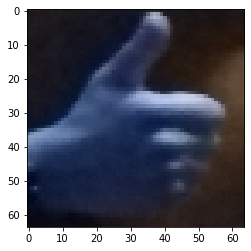

In [5]:
plt.imshow(random.sample(images, 1)[0])

## split data set into train and test

x is for the actual data, y is for the label (this is convention)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)

print(len(X_train))
print(len(X_test))
print(len(y_train))
print(len(y_test))

400
100
400
100


## transform data sets into a format compatible with our neural network

image data has to be a numpy array with following dimensions: [image_id, y_axis, x_axis, color_channels]

furthermore, scale all values to a range of 0 to 1

training data has to be converted to a categorial vector ("one hot"):

[3] --> [0, 0, 0, 1, 0, ..., 0]

In [7]:
X_train = np.array(X_train).astype('float32')
X_train = X_train / 255.

X_test = np.array(X_test).astype('float32')
X_test = X_test / 255.

y_train_one_hot = to_categorical(y_train)
y_test_one_hot = to_categorical(y_test)

train_label = y_train_one_hot
test_label = y_test_one_hot

X_train = X_train.reshape(-1, IMG_SIZE, IMG_SIZE, COLOR_CHANNELS)
X_test = X_test.reshape(-1, IMG_SIZE, IMG_SIZE, COLOR_CHANNELS)

print(X_train.shape, X_test.shape, train_label.shape, test_label.shape)

(400, 64, 64, 3) (100, 64, 64, 3) (400, 2) (100, 2)


In [51]:
# variables for hyperparameters
batch_size = 8
epochs = 50
num_classes = len(label_names)
activation = 'relu'
activation_conv = 'tanh'  # LeakyReLU
layer_count = 2
num_neurons = 64

# define model structure
# with keras, we can use a model's add() function to add layers to the network one by one
model = Sequential()

# data augmentation (this can also be done beforehand - but don't augment the test dataset!)
model.add(RandomFlip('horizontal'))
model.add(RandomContrast(0.1))
#model.add(RandomBrightness(0.1))
#model.add(RandomRotation(0.2))

# first, we add some convolution layers followed by max pooling
model.add(Conv2D(64, kernel_size=(9, 9), activation=activation_conv, input_shape=(SIZE[0], SIZE[1], COLOR_CHANNELS), padding='same'))
model.add(MaxPooling2D(pool_size=(4, 4), padding='same'))

model.add(Conv2D(32, (5, 5), activation=activation_conv, padding='same'))
model.add(MaxPooling2D(pool_size=(3, 3), padding='same'))

model.add(Conv2D(32, (3, 3), activation=activation_conv, padding='same'))
model.add(MaxPooling2D(pool_size=(2, 2), padding='same'))

# dropout layers can drop part of the data during each epoch - this prevents overfitting
model.add(Dropout(0.2))

# after the convolution layers, we have to flatten the data so it can be fed into fully connected layers
model.add(Flatten())

# add some fully connected layers ("Dense")
for i in range(layer_count - 1):
    model.add(Dense(num_neurons, activation=activation))

model.add(Dense(num_neurons, activation=activation))

# for classification, the last layer has to use the softmax activation function, which gives us probabilities for each category
model.add(Dense(num_classes, activation='softmax'))

# specify loss function, optimizer and evaluation metrics
# for classification, categorial crossentropy is used as a loss function
# use the adam optimizer unless you have a good reason not to
model.compile(loss=categorical_crossentropy, optimizer="adam", metrics=['accuracy'])

/Users/thule/opt/anaconda3/lib/python3.9/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## now, we can train the model using the fit() function
## this will take a while

In [52]:
history = model.fit(
    X_train,
    train_label,
    batch_size=batch_size,
    epochs=epochs,
    verbose=1,
    validation_data=(X_test, test_label),
    callbacks=[]
)

Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step - accuracy: 0.5115 - loss: 0.7368 - val_accuracy: 0.4600 - val_loss: 0.7144
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.5391 - loss: 0.7010 - val_accuracy: 0.7100 - val_loss: 0.6326
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.6118 - loss: 0.6667 - val_accuracy: 0.6800 - val_loss: 0.6566
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.5510 - loss: 0.6988 - val_accuracy: 0.5400 - val_loss: 0.6869
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.5688 - loss: 0.7395 - val_accuracy: 0.4600 - val_loss: 0.7006
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.5383 - loss: 0.6958 - val_accuracy: 0.5400 - val_loss: 0.7185
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.4520 - loss: 0.7522 - val_accuracy: 0.7000 - val_loss: 0.6777
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.5321 - loss: 0.6842 - val_accuracy: 0.7300 - v

In [10]:
# let's have a look at our model
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (8, 64, 64, 3)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast                 │ (8, 64, 64, 3)         │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (8, 64, 64, 64)        │        15,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (8, 16, 16, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (8, 16, 16, 32)        │        51,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (8, 6, 6, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (8, 6, 6, 32)          │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (8, 3, 3, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (8, 3, 3, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (8, 288)               │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (8, 64)                │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (8, 64)                │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (8, 2)                 │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 296,648 (1.13 MB)

 Trainable params: 98,882 (386.26 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 197,766 (772.53 KB)

## Plot accuracy and loss of the training process

In [ ]:
loss = history.history['loss']
val_loss = history.history['val_loss']
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

fig = plt.figure(figsize=(15, 7))
ax = plt.gca()

ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy (Line), Loss (Dashes)')

ax.axhline(1, color='gray')

plt.plot(accuracy, color='blue')
plt.plot(val_accuracy, color='orange')
plt.plot(loss, '--', color='blue', alpha=0.5)
plt.plot(val_loss, '--', color='orange', alpha=0.5)

## Sigmoid
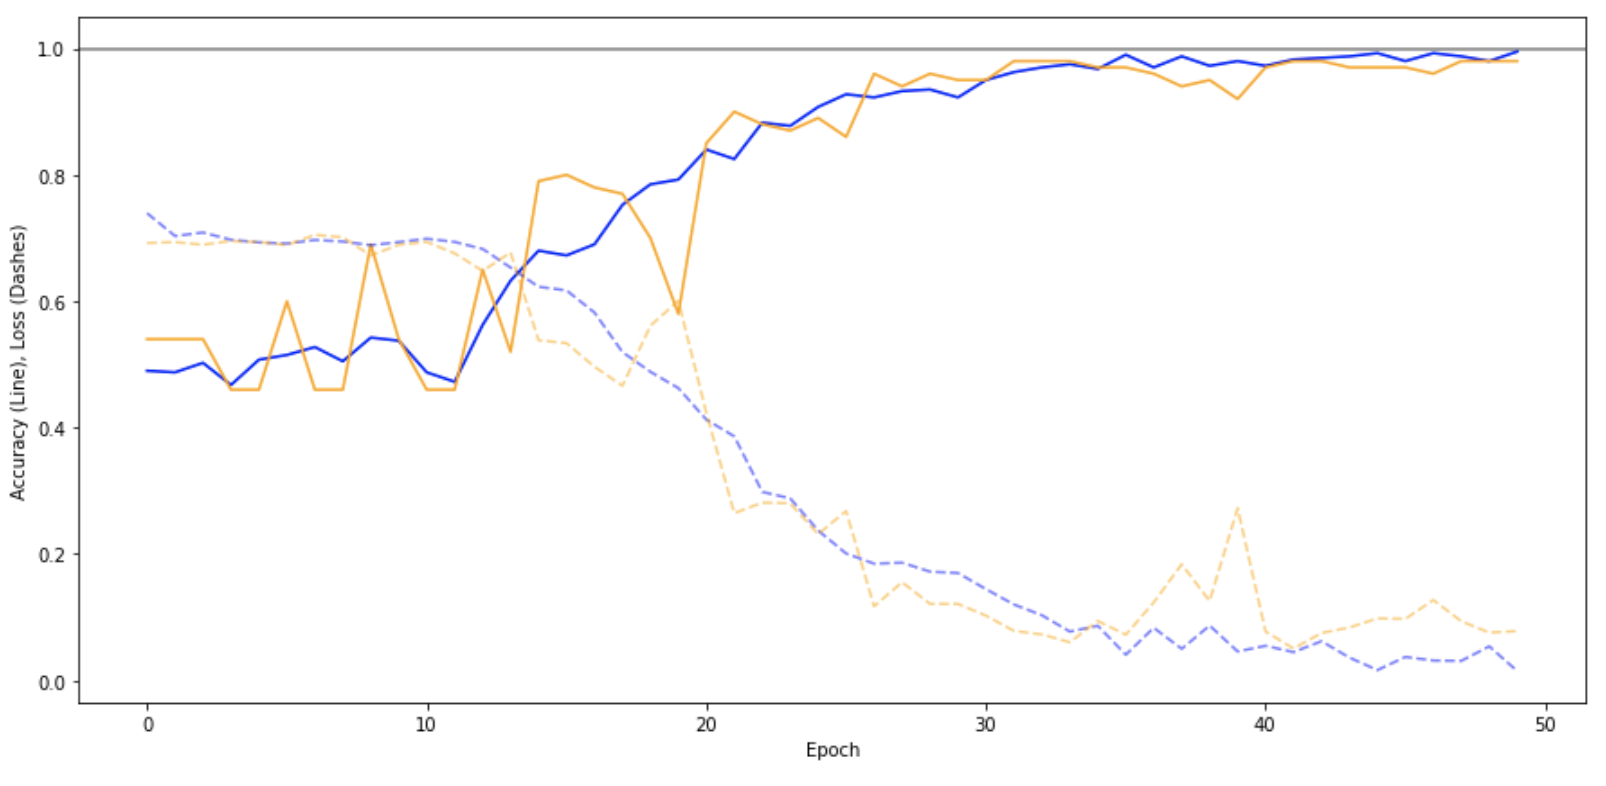

## ReLU
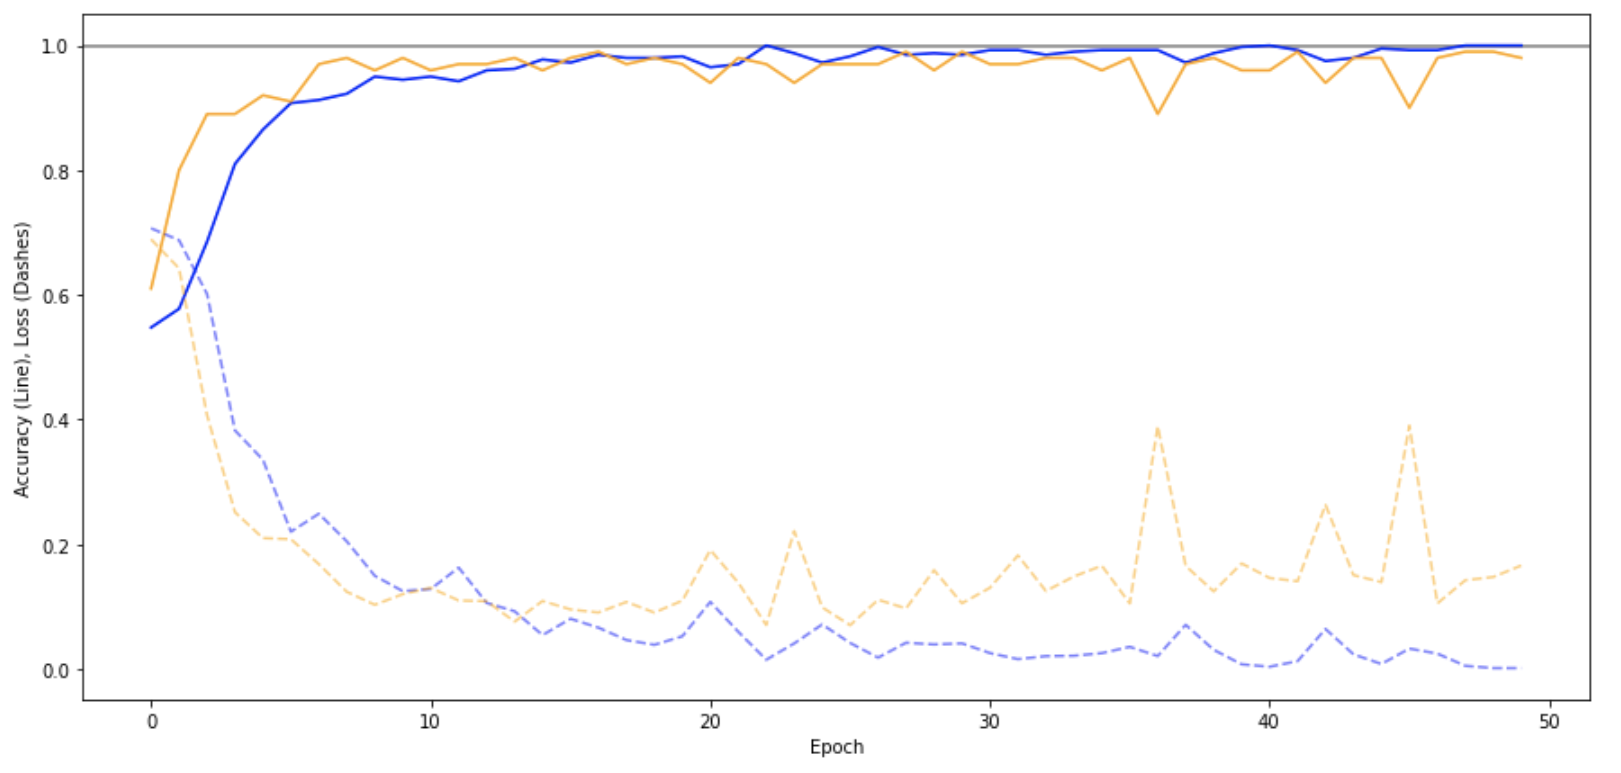

## ELU
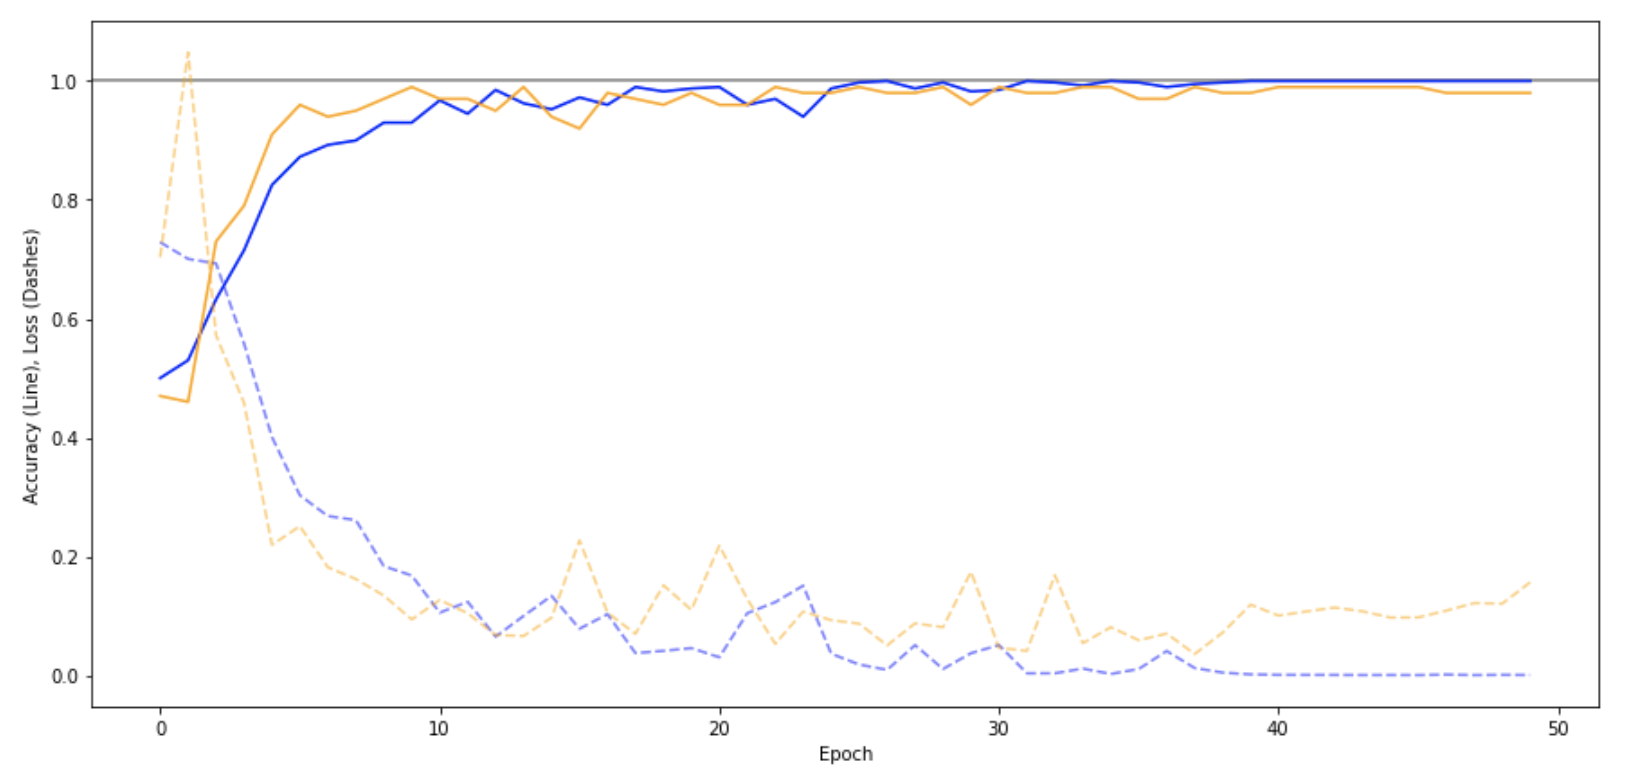

## SELU
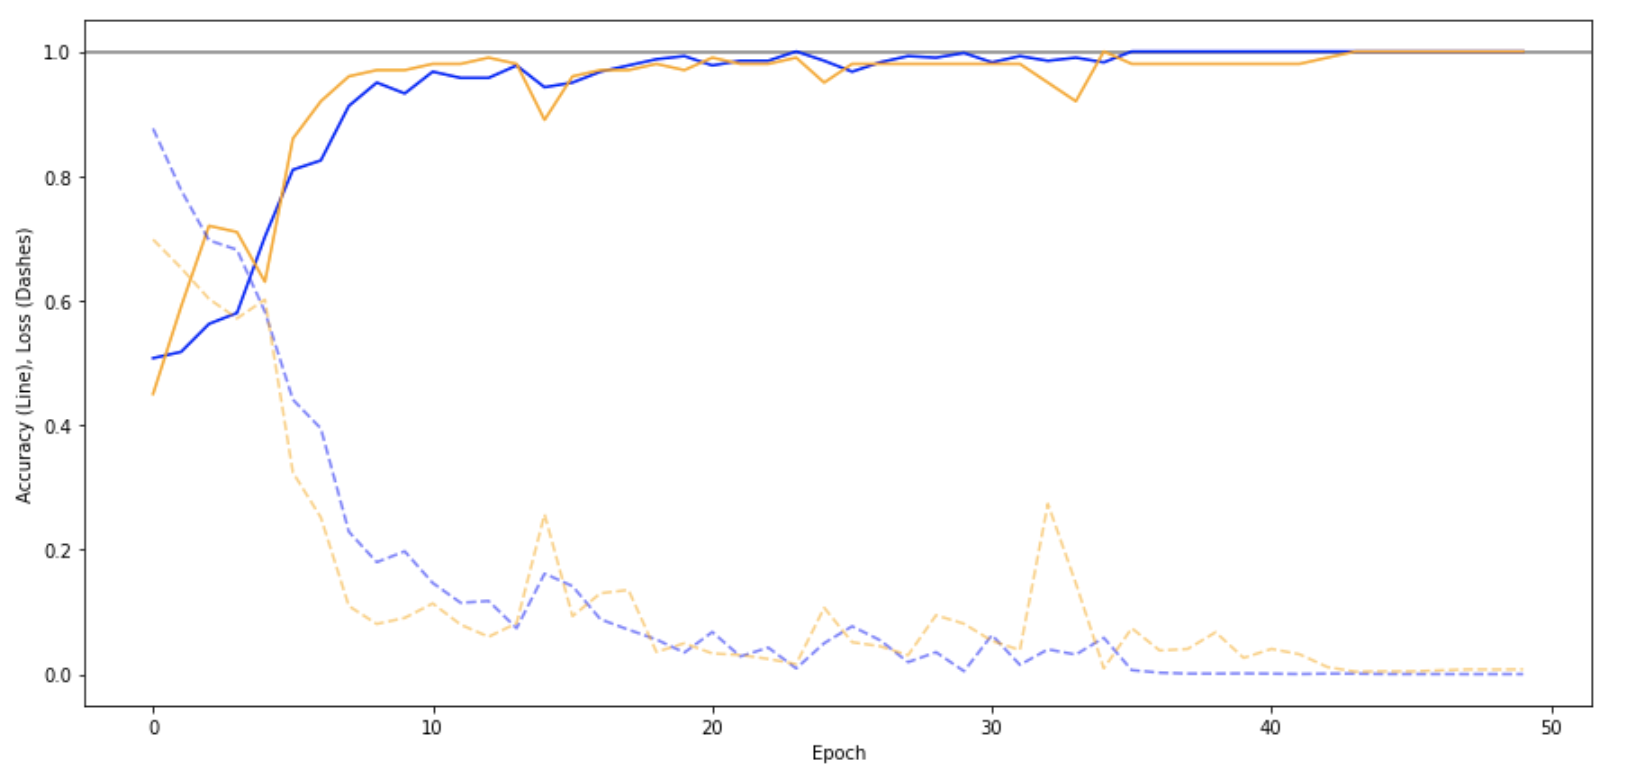

## Tanh
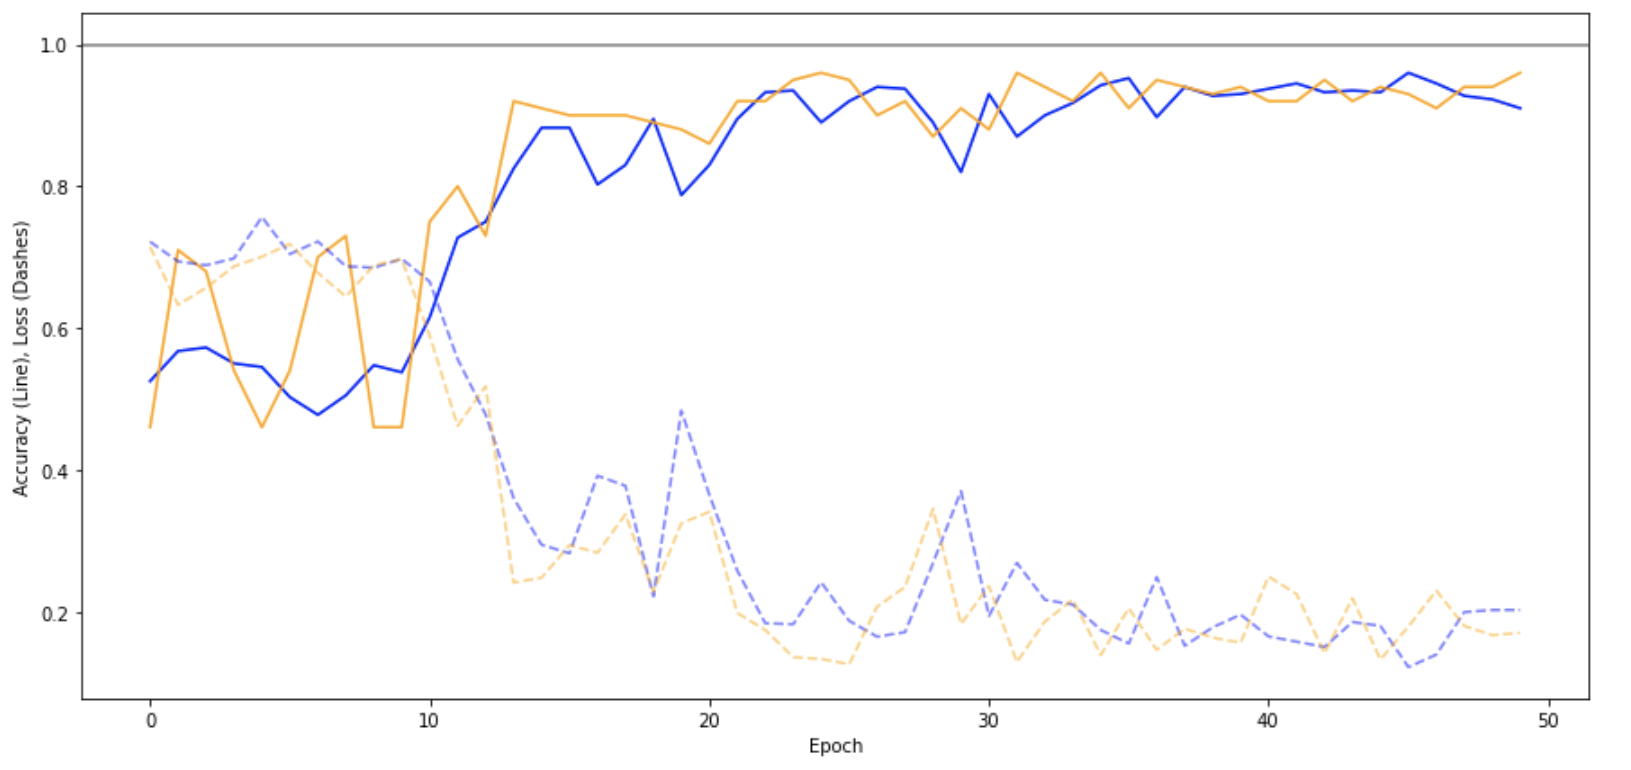

## saving the models

The trained models are saved using the Keras format (.keras).

Since this experiment compares different activation functions, each model is saved with the corresponding activation function in the filename. This allows the models to be loaded and compared later without retraining.

Examples:
- gesture_classifier_relu.keras
- gesture_classifier_elu.keras
- gesture_classifier_selu.keras
- gesture_classifier_tanh.keras
- gesture_classifier_sigmoid.keras

The .keras format stores both the model architecture and the trained weights and is the recommended format in modern Keras versions.

In [54]:
model.save(f'gesture_classifier_{activation_conv}.keras')

# Example:
# keras.models.load_model("gesture_classifier_relu.keras")

## visualize classification results with a confusion matrix

In [ ]:
# let the model make predictions for our training data
y_predictions = model.predict(X_test)

# we get a 2D numpy array with probabilities for each category
print('before', y_predictions)

# to build a confusion matrix, we have to convert it to classifications
# this can be done by using the argmax() function to set the probability to 1 and the rest to 0
y_predictions = np.argmax(y_predictions, axis=1)

print('probabilities', y_predictions)

# create and plot confusion matrix
conf_matrix = confusion_matrix(y_test, y_predictions)

fig = plt.figure(figsize=(10, 10))

ConfusionMatrixDisplay(conf_matrix, display_labels=label_names).plot(ax=plt.gca())

plt.xticks(rotation=90, ha='center')
pass

## Sigmoid
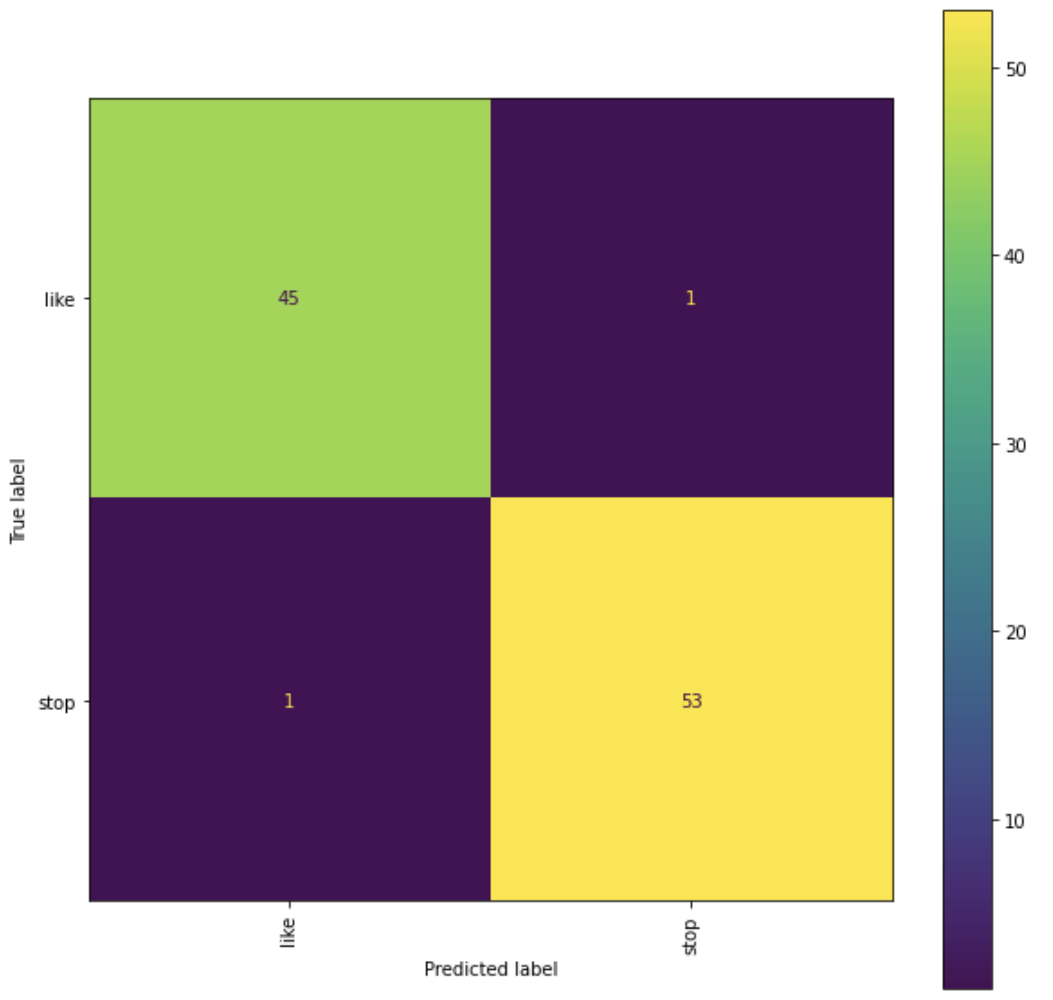

## ReLU
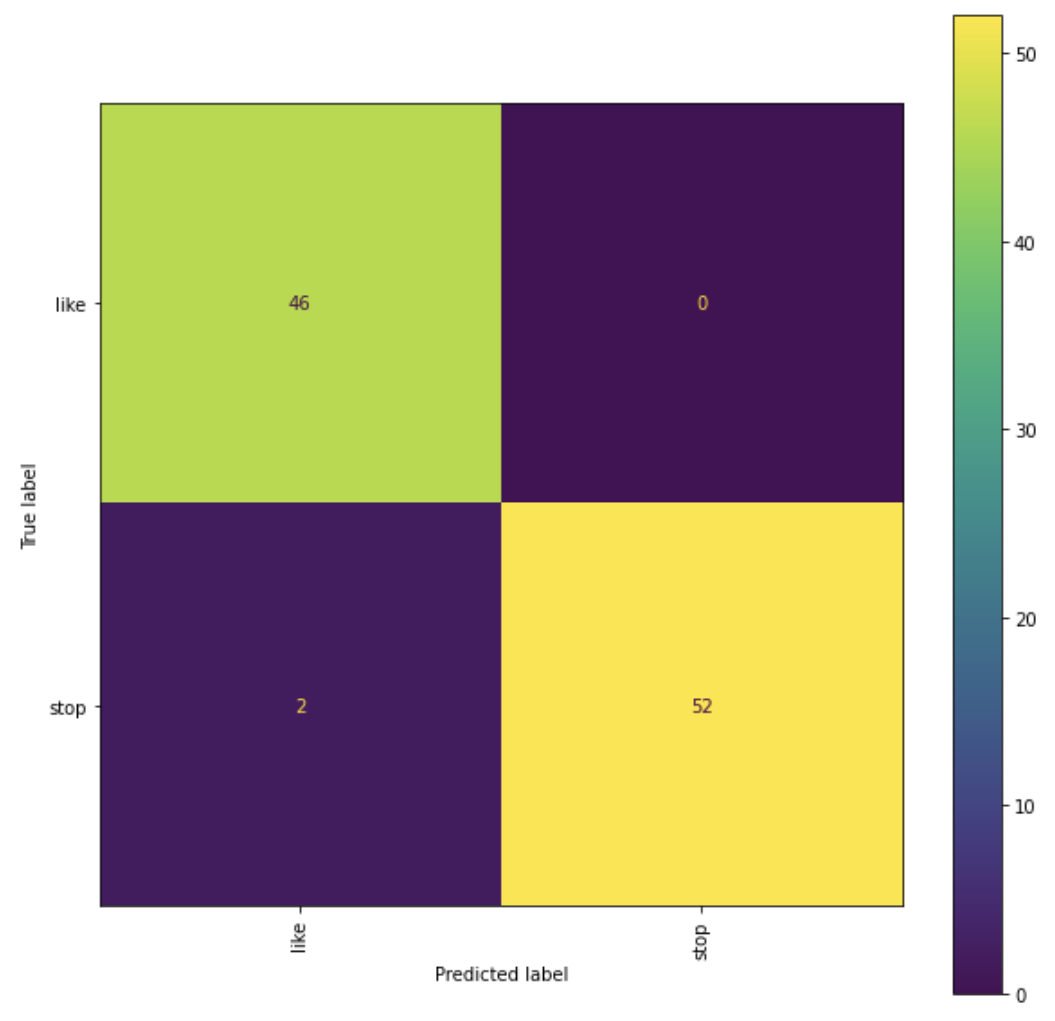

## ELU
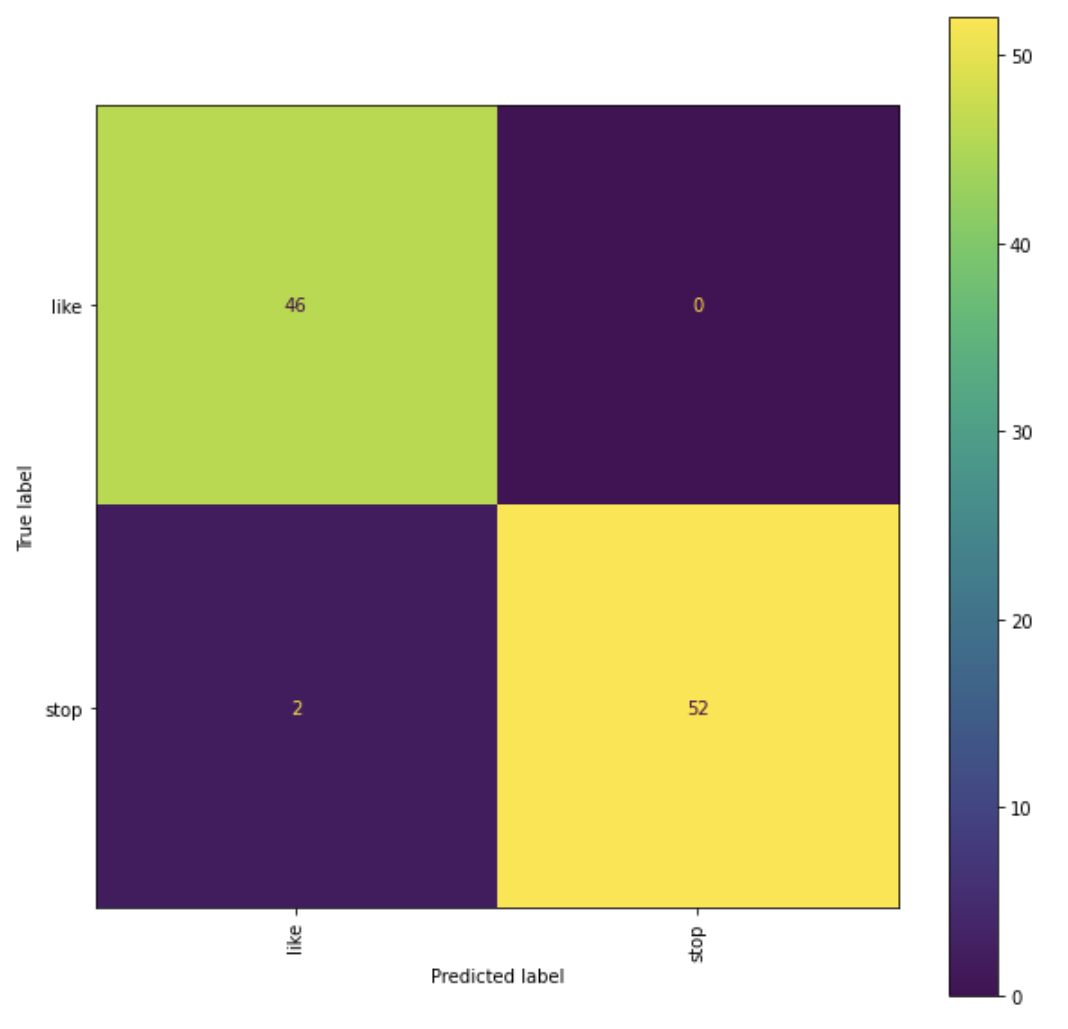

## SELU
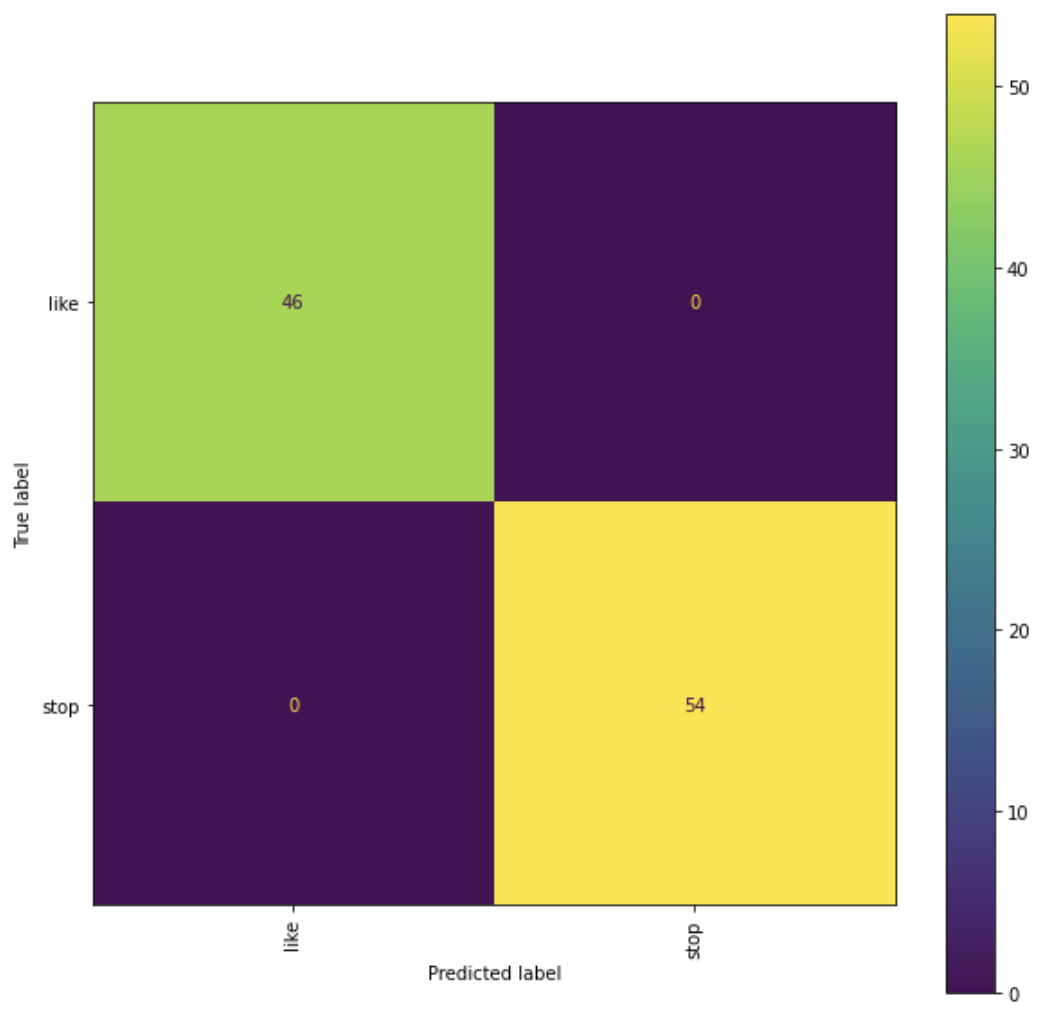

## Tanh
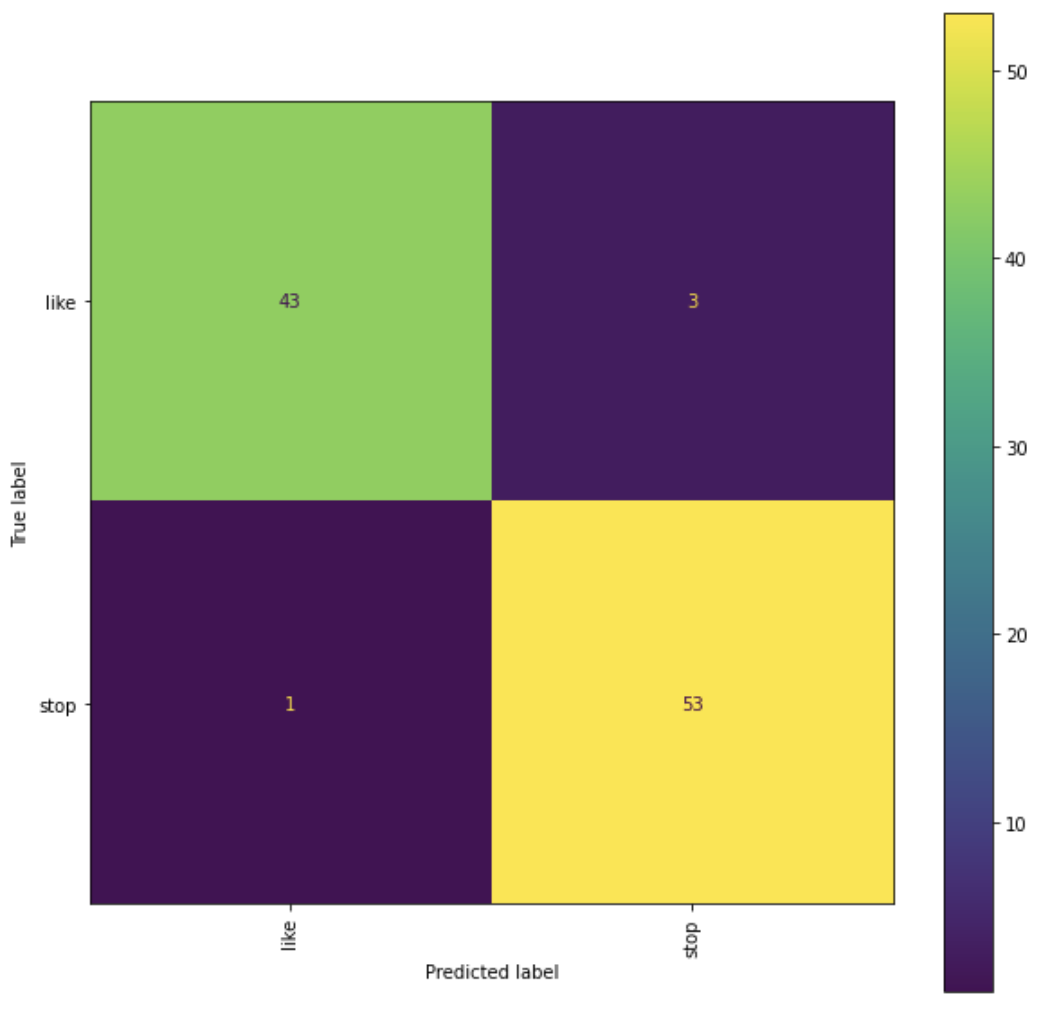

## Evaluation of activation function Performance
The goal of this experiment is to compare different activation functions used in convolution layers. All other hyperparameters are kept constant. The final test accuracy is recorded for each activation function.

In [56]:
test_loss, test_acc = model.evaluate(
    X_test,
    test_label,
    verbose=0
)

try:
    results
except NameError:
    results = []

results.append({
    "activation": activation_conv,
    "accuracy": test_acc
})

print(results)

[{'activation': 'sigmoid', 'accuracy': 0.9800000190734863}, {'activation': 'relu', 'accuracy': 0.9800000190734863}, {'activation': 'elu', 'accuracy': 0.9800000190734863}, {'activation': 'selu', 'accuracy': 1.0}, {'activation': 'tanh', 'accuracy': 0.9599999785423279}]


In [57]:
import pandas as pd

df = pd.DataFrame(results)

df

,activation,accuracy
0,sigmoid,0.98
1,relu,0.98
2,elu,0.98
3,selu,1.00
4,tanh,0.96


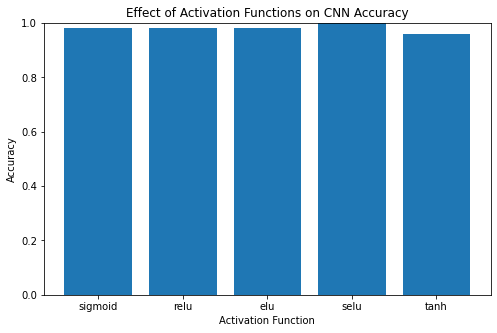

In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(df["activation"], df["accuracy"])

plt.xlabel("Activation Function")
plt.ylabel("Accuracy")
plt.title("Effect of Activation Functions on CNN Accuracy")

plt.ylim(0,1)

plt.savefig(
    "activation_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Findings and discussion

The results show that the choice of activation function has a measurable impact on the performance of the CNN, although the differences between the best-performing functions are relatively small.

SELU achieved the highest accuracy in the final experiment, reaching 100% classification accuracy on the test set. ReLU, ELU and Sigmoid also performed very well, each achieving approximately 98% accuracy. Tanh produced the lowest accuracy at approximately 96%.

The experiment was repeated multiple times. While the exact accuracy values varied slightly between runs, similar trends were observed overall. These variations are expected because neural networks start with randomly initialized weights and the dataset used in this assignment is relatively small. As a result, small changes in the training process can lead to minor differences in the final accuracy.

One interesting observation is that SELU consistently performed among the strongest activation functions. This may be related to its self-normalizing behavior, which can help maintain stable activations throughout the network. ReLU and ELU also produced strong and reliable results, which is consistent with their widespread use in modern CNN architectures.

Tanh generally achieved the lowest performance. This supports the original assumption that saturation effects can make optimization more difficult and reduce training efficiency compared to more modern activation functions.

Overall, the experiment suggests that activation functions can influence the learning behavior of convolutional layers. For this hand gesture recognition task, SELU provided the best final performance, while ReLU and ELU remained competitive and reliable alternatives.
Because the differences between the top-performing activation functions were relatively small, further experiments with larger datasets would be required to determine whether the observed performance differences are statistically significant.
